# Comprehensive Dermatology Dataset Analysis

This notebook provides a unified analysis of all available dermatology datasets:
- **DDI (Diverse Dermatology Images)**: 656 samples, 78 diseases
- **Fitzpatrick17k**: 16,577 samples, 114 diseases
- **SCIN**: 5,033 samples, 60+ skin conditions
- **SkinCAP**: 4,000+ samples, 50+ diseases
- **DermNet**: Comprehensive dermatology dataset with train/test splits


In [ ]:
pip install seaborn kagglehub


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from collections import Counter
import warnings
import kagglehub
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10


## 1. Load All Datasets


In [ ]:
# Load DDI dataset
ddi_df = pd.read_csv('data/ddidiversedermatologyimages/ddi_metadata.csv')
print(f"DDI Dataset: {ddi_df.shape[0]} samples, {ddi_df['disease'].nunique()} diseases")

# Load Fitzpatrick17k dataset
fitz_df = pd.read_csv('data/fitzpatrick17k/fitzpatrick17k.csv')
print(f"Fitzpatrick17k Dataset: {fitz_df.shape[0]} samples, {fitz_df['label'].nunique()} diseases")

# Load SCIN dataset
scin_df = pd.read_csv('data/scin/dataset/scin_labels.csv')
print(f"SCIN Dataset: {scin_df.shape[0]} samples")

# Load SkinCAP dataset
skincap_df = pd.read_csv('data/skincap/skincap_v240623.csv')
print(f"SkinCAP Dataset: {skincap_df.shape[0]} samples, {skincap_df['disease'].nunique()} diseases")

print("\nAll datasets loaded successfully!")


DDI Dataset: 656 samples, 78 diseases


Fitzpatrick17k Dataset: 16577 samples, 114 diseases
SCIN Dataset: 5033 samples
SkinCAP Dataset: 4000 samples, 187 diseases

All datasets loaded successfully!


## 2. Process SCIN Dataset (Extract Most Confident Labels)


In [ ]:
# Function to extract the most confident label from SCIN dataset
def get_most_confident_label(row):
    try:
        labels = ast.literal_eval(row['dermatologist_skin_condition_on_label_name'])
        confidences = ast.literal_eval(row['dermatologist_skin_condition_confidence'])
        
        if not labels or not confidences:
            return None
            
        max_conf_idx = np.argmax(confidences)
        return labels[max_conf_idx]
        
    except (ValueError, SyntaxError, TypeError):
        return None

# Apply the function to get most confident labels
scin_df['most_confident_label'] = scin_df.apply(get_most_confident_label, axis=1)
scin_df_with_labels = scin_df.dropna(subset=['most_confident_label'])

print(f"SCIN Dataset with valid labels: {scin_df_with_labels.shape[0]} samples, {scin_df_with_labels['most_confident_label'].nunique()} unique conditions")
print(f"Label extraction success rate: {len(scin_df_with_labels)/len(scin_df)*100:.1f}%")


SCIN Dataset with valid labels: 3061 samples, 210 unique conditions
Label extraction success rate: 60.8%


## 3. DermNet Dataset Analysis - Proper Disease Category Analysis


In [ ]:
# Download DermNet dataset
print("Downloading DermNet dataset...")
path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Path to dataset files:", path)

# Explore the dataset structure
dataset_path = Path(path)
print(f"\nDataset structure:")
for item in dataset_path.iterdir():
    if item.is_dir():
        print(f"📁 {item.name}/")
        # List contents of subdirectories
        try:
            subitems = list(item.iterdir())
            for subitem in subitems[:5]:  # Show first 5 items
                if subitem.is_dir():
                    print(f"  📁 {subitem.name}/")
                else:
                    print(f"  📄 {subitem.name}")
            if len(subitems) > 5:
                print(f"  ... and {len(subitems) - 5} more items")
        except PermissionError:
            print(f"  (Permission denied to list contents)")
    else:
        print(f"📄 {item.name}")


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1

Dataset structure:
📁 test/
  📁 Acne and Rosacea Photos/
  📁 Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions/
  📁 Atopic Dermatitis Photos/
  📁 Bullous Disease Photos/
  📁 Cellulitis Impetigo and other Bacterial Infections/
  ... and 18 more items
📁 train/
  📁 Acne and Rosacea Photos/
  📁 Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions/
  📁 Atopic Dermatitis Photos/
  📁 Bullous Disease Photos/
  📁 Cellulitis Impetigo and other Bacterial Infections/
  ... and 18 more items


In [ ]:
# PROPER ANALYSIS: Combine train and test datasets to get complete disease categories
print("=" * 80)
print("PROPER DERMNET ANALYSIS - COMBINING TRAIN AND TEST DATASETS")
print("=" * 80)

# Get disease categories from both train and test folders
train_path = Path(path) / "train"
test_path = Path(path) / "test"

# Dictionary to store combined disease counts
combined_disease_counts = {}
train_disease_counts = {}
test_disease_counts = {}

print("\n🔍 Analyzing disease categories in train folder...")
for disease_folder in train_path.iterdir():
    if disease_folder.is_dir():
        disease_name = disease_folder.name
        
        # Count images in this disease category
        image_count = 0
        for file in disease_folder.iterdir():
            if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
                image_count += 1
        
        train_disease_counts[disease_name] = image_count
        combined_disease_counts[disease_name] = image_count  # Initialize with train count
        print(f"📁 {disease_name}: {image_count} images (train)")

print("\n🔍 Analyzing disease categories in test folder...")
for disease_folder in test_path.iterdir():
    if disease_folder.is_dir():
        disease_name = disease_folder.name
        
        # Count images in this disease category
        image_count = 0
        for file in disease_folder.iterdir():
            if file.is_file() and file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
                image_count += 1
        
        test_disease_counts[disease_name] = image_count
        
        # Add to combined count
        if disease_name in combined_disease_counts:
            combined_disease_counts[disease_name] += image_count
        else:
            combined_disease_counts[disease_name] = image_count
        
        print(f"📁 {disease_name}: {image_count} images (test)")

# Calculate totals
total_train_images = sum(train_disease_counts.values())
total_test_images = sum(test_disease_counts.values())
total_combined_images = sum(combined_disease_counts.values())
total_disease_categories = len(combined_disease_counts)

print(f"\n📊 COMBINED DERMNET DATASET SUMMARY:")
print(f"• Total disease categories: {total_disease_categories}")
print(f"• Total images in train set: {total_train_images:,}")
print(f"• Total images in test set: {total_test_images:,}")
print(f"• Total images combined: {total_combined_images:,}")
print(f"• Average images per disease: {total_combined_images/total_disease_categories:.1f}")
print(f"• Train/Test split ratio: {total_train_images/(total_train_images + total_test_images)*100:.1f}% / {total_test_images/(total_train_images + total_test_images)*100:.1f}%")


PROPER DERMNET ANALYSIS - COMBINING TRAIN AND TEST DATASETS

🔍 Analyzing disease categories in train folder...
📁 Acne and Rosacea Photos: 840 images (train)


📁 Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 1149 images (train)
📁 Atopic Dermatitis Photos: 489 images (train)
📁 Bullous Disease Photos: 448 images (train)
📁 Cellulitis Impetigo and other Bacterial Infections: 288 images (train)
📁 Eczema Photos: 1235 images (train)
📁 Exanthems and Drug Eruptions: 404 images (train)
📁 Hair Loss Photos Alopecia and other Hair Diseases: 239 images (train)
📁 Herpes HPV and other STDs Photos: 405 images (train)
📁 Light Diseases and Disorders of Pigmentation: 568 images (train)
📁 Lupus and other Connective Tissue diseases: 420 images (train)
📁 Melanoma Skin Cancer Nevi and Moles: 463 images (train)
📁 Nail Fungus and other Nail Disease: 1040 images (train)
📁 Poison Ivy Photos and other Contact Dermatitis: 260 images (train)
📁 Psoriasis pictures Lichen Planus and related diseases: 1405 images (train)
📁 Scabies Lyme Disease and other Infestations and Bites: 431 images (train)
📁 Seborrheic Keratoses and other Benign Tumors: 1371 images 

In [ ]:
# Create comprehensive DataFrame for analysis
dermnet_analysis_data = []

for disease_name in combined_disease_counts.keys():
    train_count = train_disease_counts.get(disease_name, 0)
    test_count = test_disease_counts.get(disease_name, 0)
    total_count = combined_disease_counts[disease_name]
    
    dermnet_analysis_data.append({
        'disease': disease_name,
        'train_images': train_count,
        'test_images': test_count,
        'total_images': total_count
    })

# Create DataFrame and sort by total images
dermnet_df = pd.DataFrame(dermnet_analysis_data).sort_values('total_images', ascending=False)

print(f"\n🏆 TOP 15 DISEASE CATEGORIES (COMBINED TRAIN + TEST):")
top_15 = dermnet_df.head(15)
for i, (_, row) in enumerate(top_15.iterrows(), 1):
    print(f"  {i:2d}. {row['disease']:<50} {row['total_images']:>4} images (Train: {row['train_images']}, Test: {row['test_images']})")

print(f"\n📉 BOTTOM 10 DISEASE CATEGORIES (COMBINED TRAIN + TEST):")
bottom_10 = dermnet_df.tail(10)
for i, (_, row) in enumerate(bottom_10.iterrows(), 1):
    print(f"  {i:2d}. {row['disease']:<50} {row['total_images']:>4} images (Train: {row['train_images']}, Test: {row['test_images']})")

# Detailed statistics
print(f"\n📊 DETAILED STATISTICS:")
print(f"• Average images per disease: {dermnet_df['total_images'].mean():.1f}")
print(f"• Median images per disease: {dermnet_df['total_images'].median():.1f}")
print(f"• Standard deviation: {dermnet_df['total_images'].std():.1f}")
print(f"• Min images per disease: {dermnet_df['total_images'].min()}")
print(f"• Max images per disease: {dermnet_df['total_images'].max()}")

# Class imbalance analysis
max_images = dermnet_df['total_images'].max()
min_images = dermnet_df['total_images'].min()
imbalance_ratio = max_images / min_images if min_images > 0 else float('inf')
print(f"\n⚖️ CLASS IMBALANCE ANALYSIS:")
print(f"• Imbalance ratio (max/min): {imbalance_ratio:.1f}:1")

# Training suitability analysis
trainable_diseases = dermnet_df[dermnet_df['total_images'] >= 20]
trainable_images = trainable_diseases['total_images'].sum()
print(f"\n🎯 TRAINING SUITABILITY:")
print(f"• Diseases suitable for training (≥20 images): {len(trainable_diseases)}/{total_disease_categories}")
print(f"• Images in trainable diseases: {trainable_images:,}/{total_combined_images:,} ({trainable_images/total_combined_images*100:.1f}%)")



🏆 TOP 15 DISEASE CATEGORIES (COMBINED TRAIN + TEST):
   1. Psoriasis pictures Lichen Planus and related diseases 1757 images (Train: 1405, Test: 352)
   2. Seborrheic Keratoses and other Benign Tumors       1714 images (Train: 1371, Test: 343)
   3. Tinea Ringworm Candidiasis and other Fungal Infections 1625 images (Train: 1300, Test: 325)
   4. Eczema Photos                                      1544 images (Train: 1235, Test: 309)
   5. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions 1437 images (Train: 1149, Test: 288)
   6. Warts Molluscum and other Viral Infections         1358 images (Train: 1086, Test: 272)
   7. Nail Fungus and other Nail Disease                 1301 images (Train: 1040, Test: 261)
   8. Acne and Rosacea Photos                            1152 images (Train: 840, Test: 312)
   9. Systemic Disease                                    758 images (Train: 606, Test: 152)
  10. Light Diseases and Disorders of Pigmentation        711 images (Train: 56

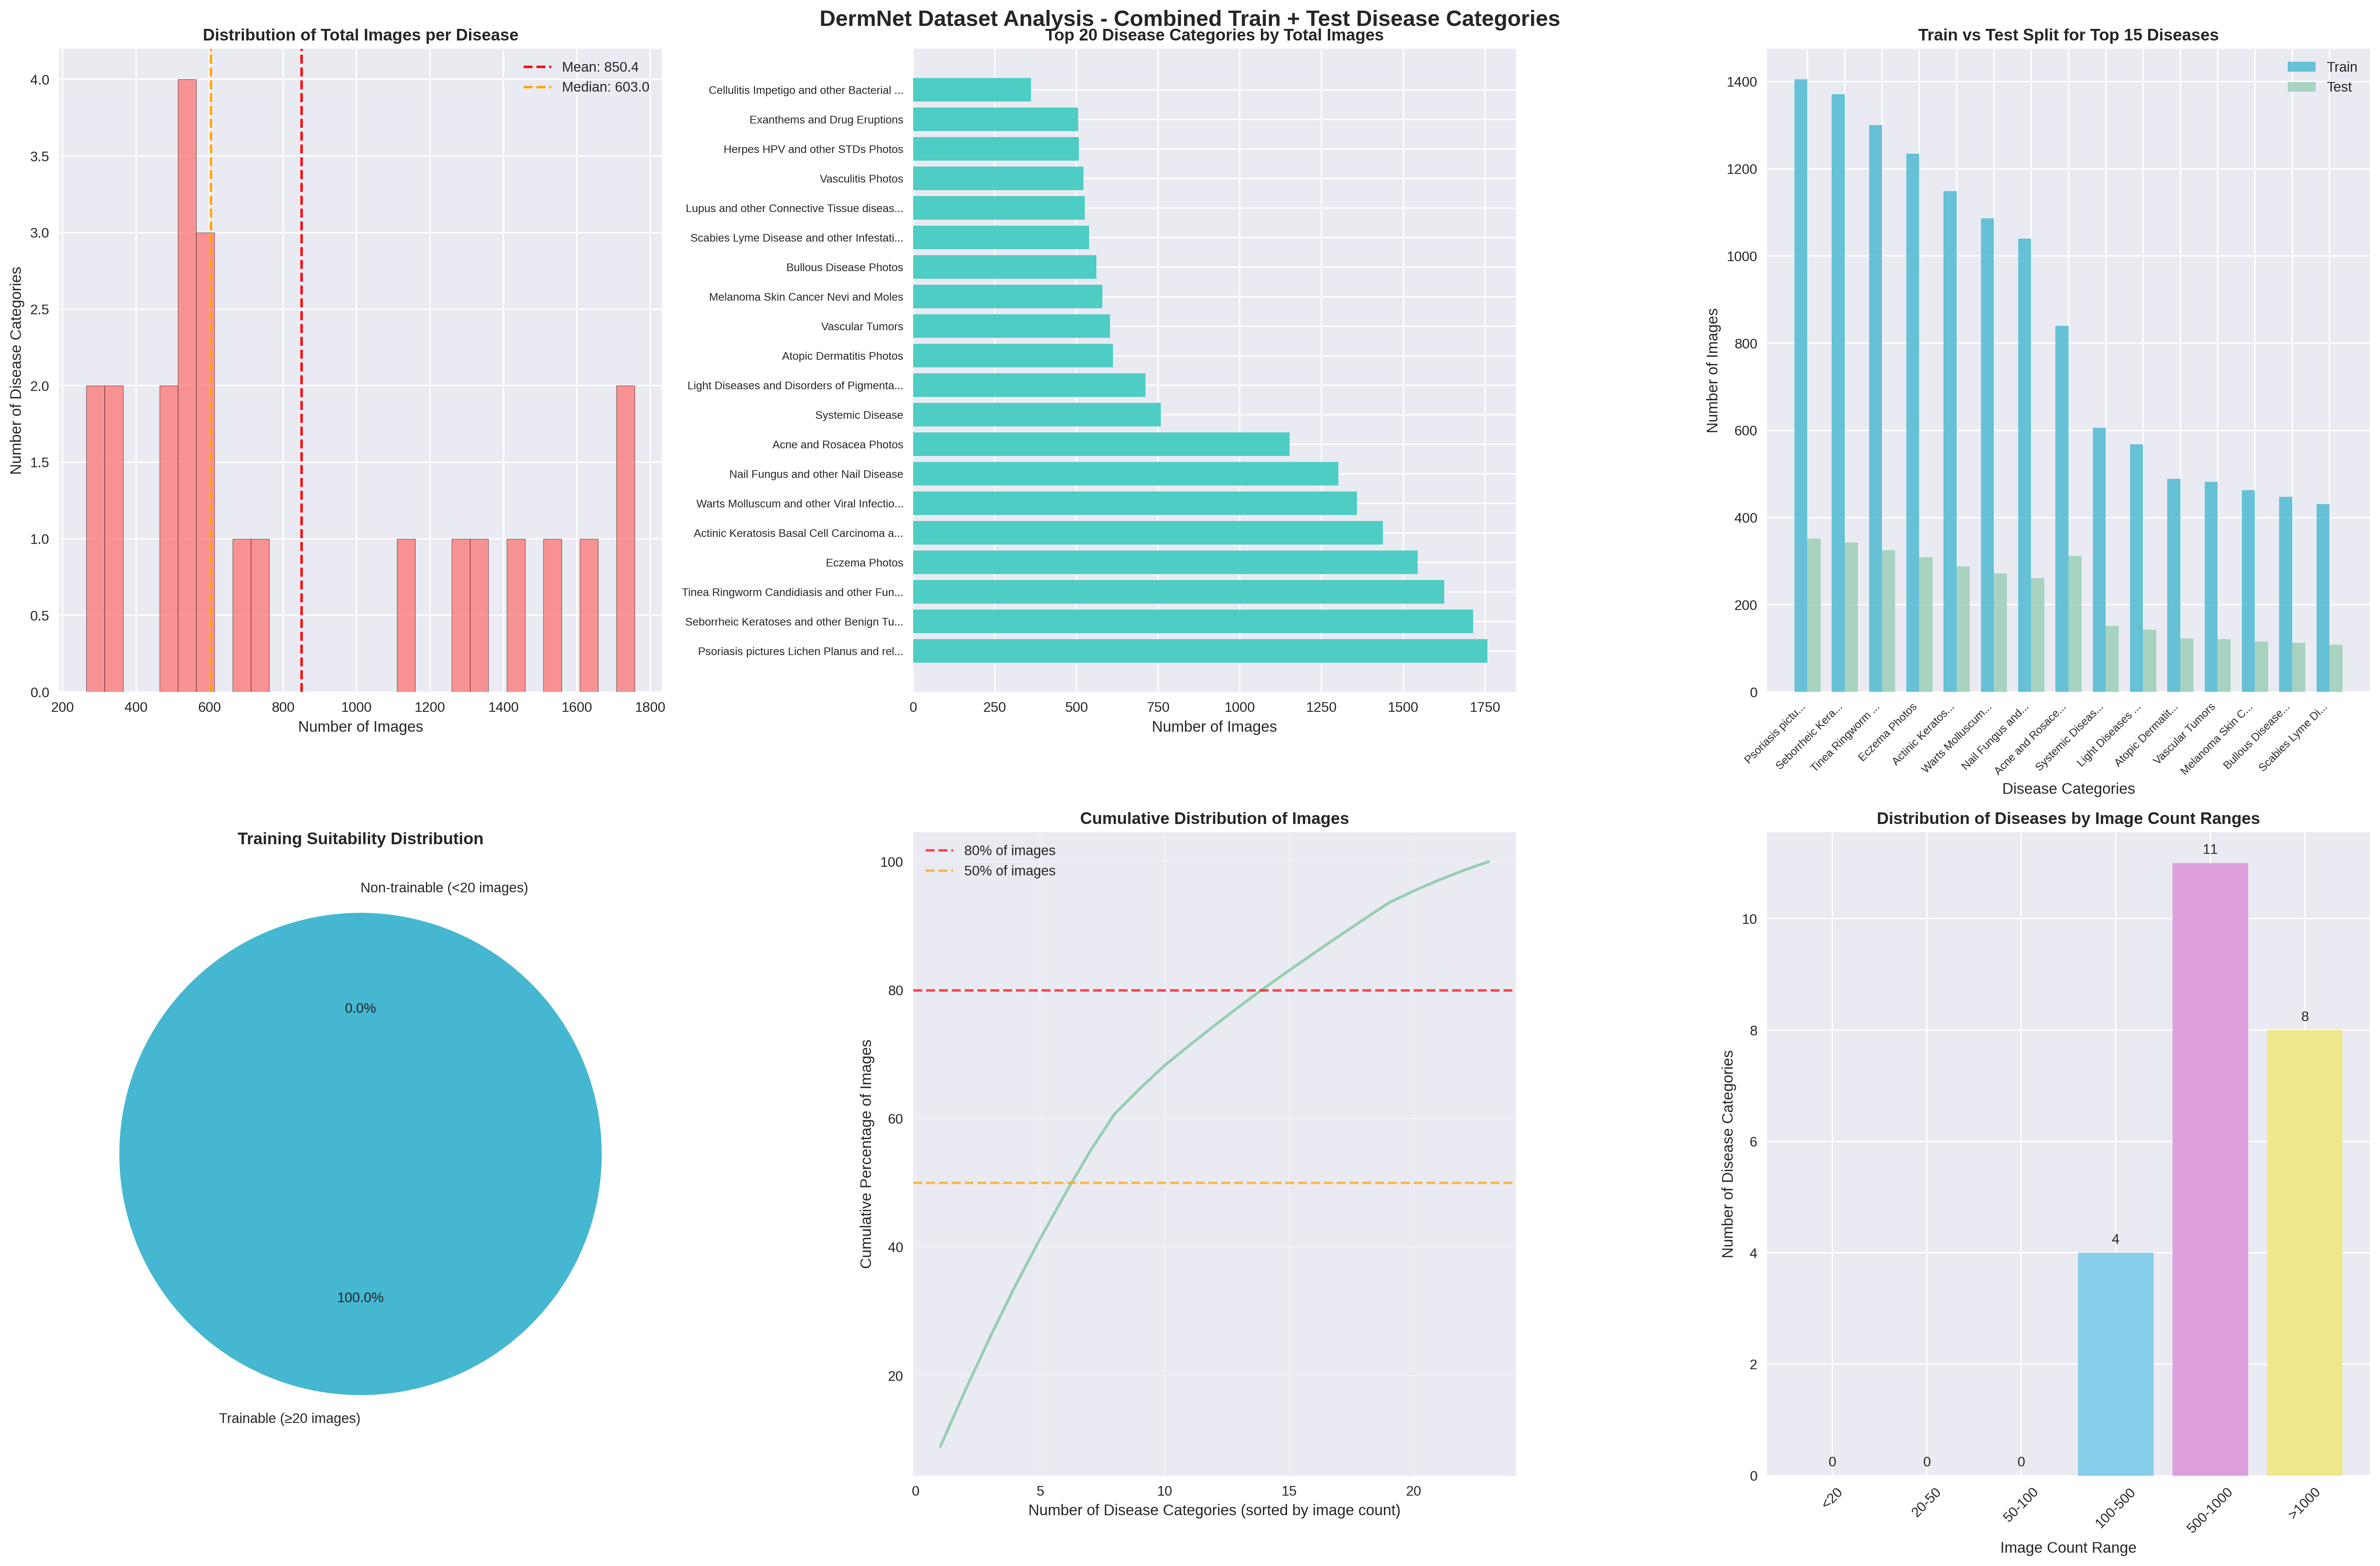

DermNet combined analysis visualization saved as 'dermnet_combined_analysis.png'


In [ ]:
# Create comprehensive visualizations for DermNet dataset
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('DermNet Dataset Analysis - Combined Train + Test Disease Categories', fontsize=16, fontweight='bold')

# 1. Distribution of total images per disease
axes[0, 0].hist(dermnet_df['total_images'], bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Total Images per Disease', fontweight='bold')
axes[0, 0].set_xlabel('Number of Images')
axes[0, 0].set_ylabel('Number of Disease Categories')
axes[0, 0].axvline(dermnet_df['total_images'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {dermnet_df["total_images"].mean():.1f}')
axes[0, 0].axvline(dermnet_df['total_images'].median(), color='orange', linestyle='--', 
                   label=f'Median: {dermnet_df["total_images"].median():.1f}')
axes[0, 0].legend()

# 2. Top 20 diseases by total image count
top_20 = dermnet_df.head(20)
axes[0, 1].barh(range(len(top_20)), top_20['total_images'], color='#4ECDC4')
axes[0, 1].set_yticks(range(len(top_20)))
axes[0, 1].set_yticklabels([disease[:40] + '...' if len(disease) > 40 else disease for disease in top_20['disease']], fontsize=8)
axes[0, 1].set_title('Top 20 Disease Categories by Total Images', fontweight='bold')
axes[0, 1].set_xlabel('Number of Images')

# 3. Train vs Test distribution for top 15 diseases
top_15_for_split = dermnet_df.head(15)
x = np.arange(len(top_15_for_split))
width = 0.35

axes[0, 2].bar(x - width/2, top_15_for_split['train_images'], width, label='Train', color='#45B7D1', alpha=0.8)
axes[0, 2].bar(x + width/2, top_15_for_split['test_images'], width, label='Test', color='#96CEB4', alpha=0.8)
axes[0, 2].set_title('Train vs Test Split for Top 15 Diseases', fontweight='bold')
axes[0, 2].set_xlabel('Disease Categories')
axes[0, 2].set_ylabel('Number of Images')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([disease[:15] + '...' if len(disease) > 15 else disease for disease in top_15_for_split['disease']], 
                           rotation=45, ha='right', fontsize=8)
axes[0, 2].legend()

# 4. Training suitability pie chart
trainable_count = len(trainable_diseases)
non_trainable_count = len(dermnet_df) - trainable_count
labels = ['Trainable (≥20 images)', 'Non-trainable (<20 images)']
sizes = [trainable_count, non_trainable_count]
colors = ['#45B7D1', '#FFB6C1']
axes[1, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Training Suitability Distribution', fontweight='bold')

# 5. Cumulative distribution
sorted_counts = np.sort(dermnet_df['total_images'])[::-1]
cumulative_percentage = np.cumsum(sorted_counts) / total_combined_images * 100
axes[1, 1].plot(range(1, len(cumulative_percentage) + 1), cumulative_percentage, 
                color='#96CEB4', linewidth=2)
axes[1, 1].set_title('Cumulative Distribution of Images', fontweight='bold')
axes[1, 1].set_xlabel('Number of Disease Categories (sorted by image count)')
axes[1, 1].set_ylabel('Cumulative Percentage of Images')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of images')
axes[1, 1].axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% of images')
axes[1, 1].legend()

# 6. Image count distribution by ranges
ranges = ['<20', '20-50', '50-100', '100-500', '500-1000', '>1000']
counts = [
    len(dermnet_df[dermnet_df['total_images'] < 20]),
    len(dermnet_df[(dermnet_df['total_images'] >= 20) & (dermnet_df['total_images'] < 50)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 50) & (dermnet_df['total_images'] < 100)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 100) & (dermnet_df['total_images'] < 500)]),
    len(dermnet_df[(dermnet_df['total_images'] >= 500) & (dermnet_df['total_images'] < 1000)]),
    len(dermnet_df[dermnet_df['total_images'] >= 1000])
]

axes[1, 2].bar(ranges, counts, color=['#FFB6C1', '#FFA07A', '#98FB98', '#87CEEB', '#DDA0DD', '#F0E68C'])
axes[1, 2].set_title('Distribution of Diseases by Image Count Ranges', fontweight='bold')
axes[1, 2].set_xlabel('Image Count Range')
axes[1, 2].set_ylabel('Number of Disease Categories')
axes[1, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[1, 2].text(i, v + max(counts)*0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('dermnet_combined_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("DermNet combined analysis visualization saved as 'dermnet_combined_analysis.png'")


## 4. Updated Comprehensive Dataset Comparison (Including Proper DermNet)


In [77]:
# Update dataset overview to include properly analyzed DermNet
updated_dataset_stats = {
    'Dataset': ['DDI', 'Fitzpatrick17k', 'SCIN', 'SkinCAP', 'DermNet (Combined)'],
    'Total Samples': [
        ddi_df.shape[0],
        fitz_df.shape[0],
        scin_df_with_labels.shape[0],
        skincap_df.shape[0],
        total_combined_images
    ],
    'Unique Conditions': [
        ddi_df['disease'].nunique(),
        fitz_df['label'].nunique(),
        scin_df_with_labels['most_confident_label'].nunique(),
        skincap_df['disease'].nunique(),
        total_disease_categories
    ],
    'Avg Samples per Condition': [
        ddi_df.shape[0] / ddi_df['disease'].nunique(),
        fitz_df.shape[0] / fitz_df['label'].nunique(),
        scin_df_with_labels.shape[0] / scin_df_with_labels['most_confident_label'].nunique(),
        skincap_df.shape[0] / skincap_df['disease'].nunique(),
        total_combined_images / total_disease_categories
    ]
}

updated_overview_df = pd.DataFrame(updated_dataset_stats)
print("Updated Dataset Overview (Including Proper DermNet Analysis):")
print(updated_overview_df.to_string(index=False))

# Calculate updated totals
updated_total_samples = sum(updated_dataset_stats['Total Samples'])
updated_total_conditions = sum(updated_dataset_stats['Unique Conditions'])
print(f"\nUpdated totals across all datasets: {updated_total_samples:,} samples, {updated_total_conditions} unique conditions")

# Show the impact of adding DermNet
print(f"\n📈 IMPACT OF ADDING DERMNET:")
print(f"• Additional samples: {total_combined_images:,}")
print(f"• Additional conditions: {total_disease_categories}")
print(f"• Total increase in samples: {total_combined_images/updated_total_samples*100:.1f}%")
print(f"• Total increase in conditions: {total_disease_categories/updated_total_conditions*100:.1f}%")


Updated Dataset Overview (Including Proper DermNet Analysis):
           Dataset  Total Samples  Unique Conditions  Avg Samples per Condition
               DDI            656                 78                   8.410256
    Fitzpatrick17k          16577                114                 145.412281
              SCIN           3061                210                  14.576190
           SkinCAP           4000                187                  21.390374
DermNet (Combined)          19559                 23                 850.391304

Updated totals across all datasets: 43,853 samples, 612 unique conditions

📈 IMPACT OF ADDING DERMNET:
• Additional samples: 19,559
• Additional conditions: 23
• Total increase in samples: 44.6%
• Total increase in conditions: 3.8%


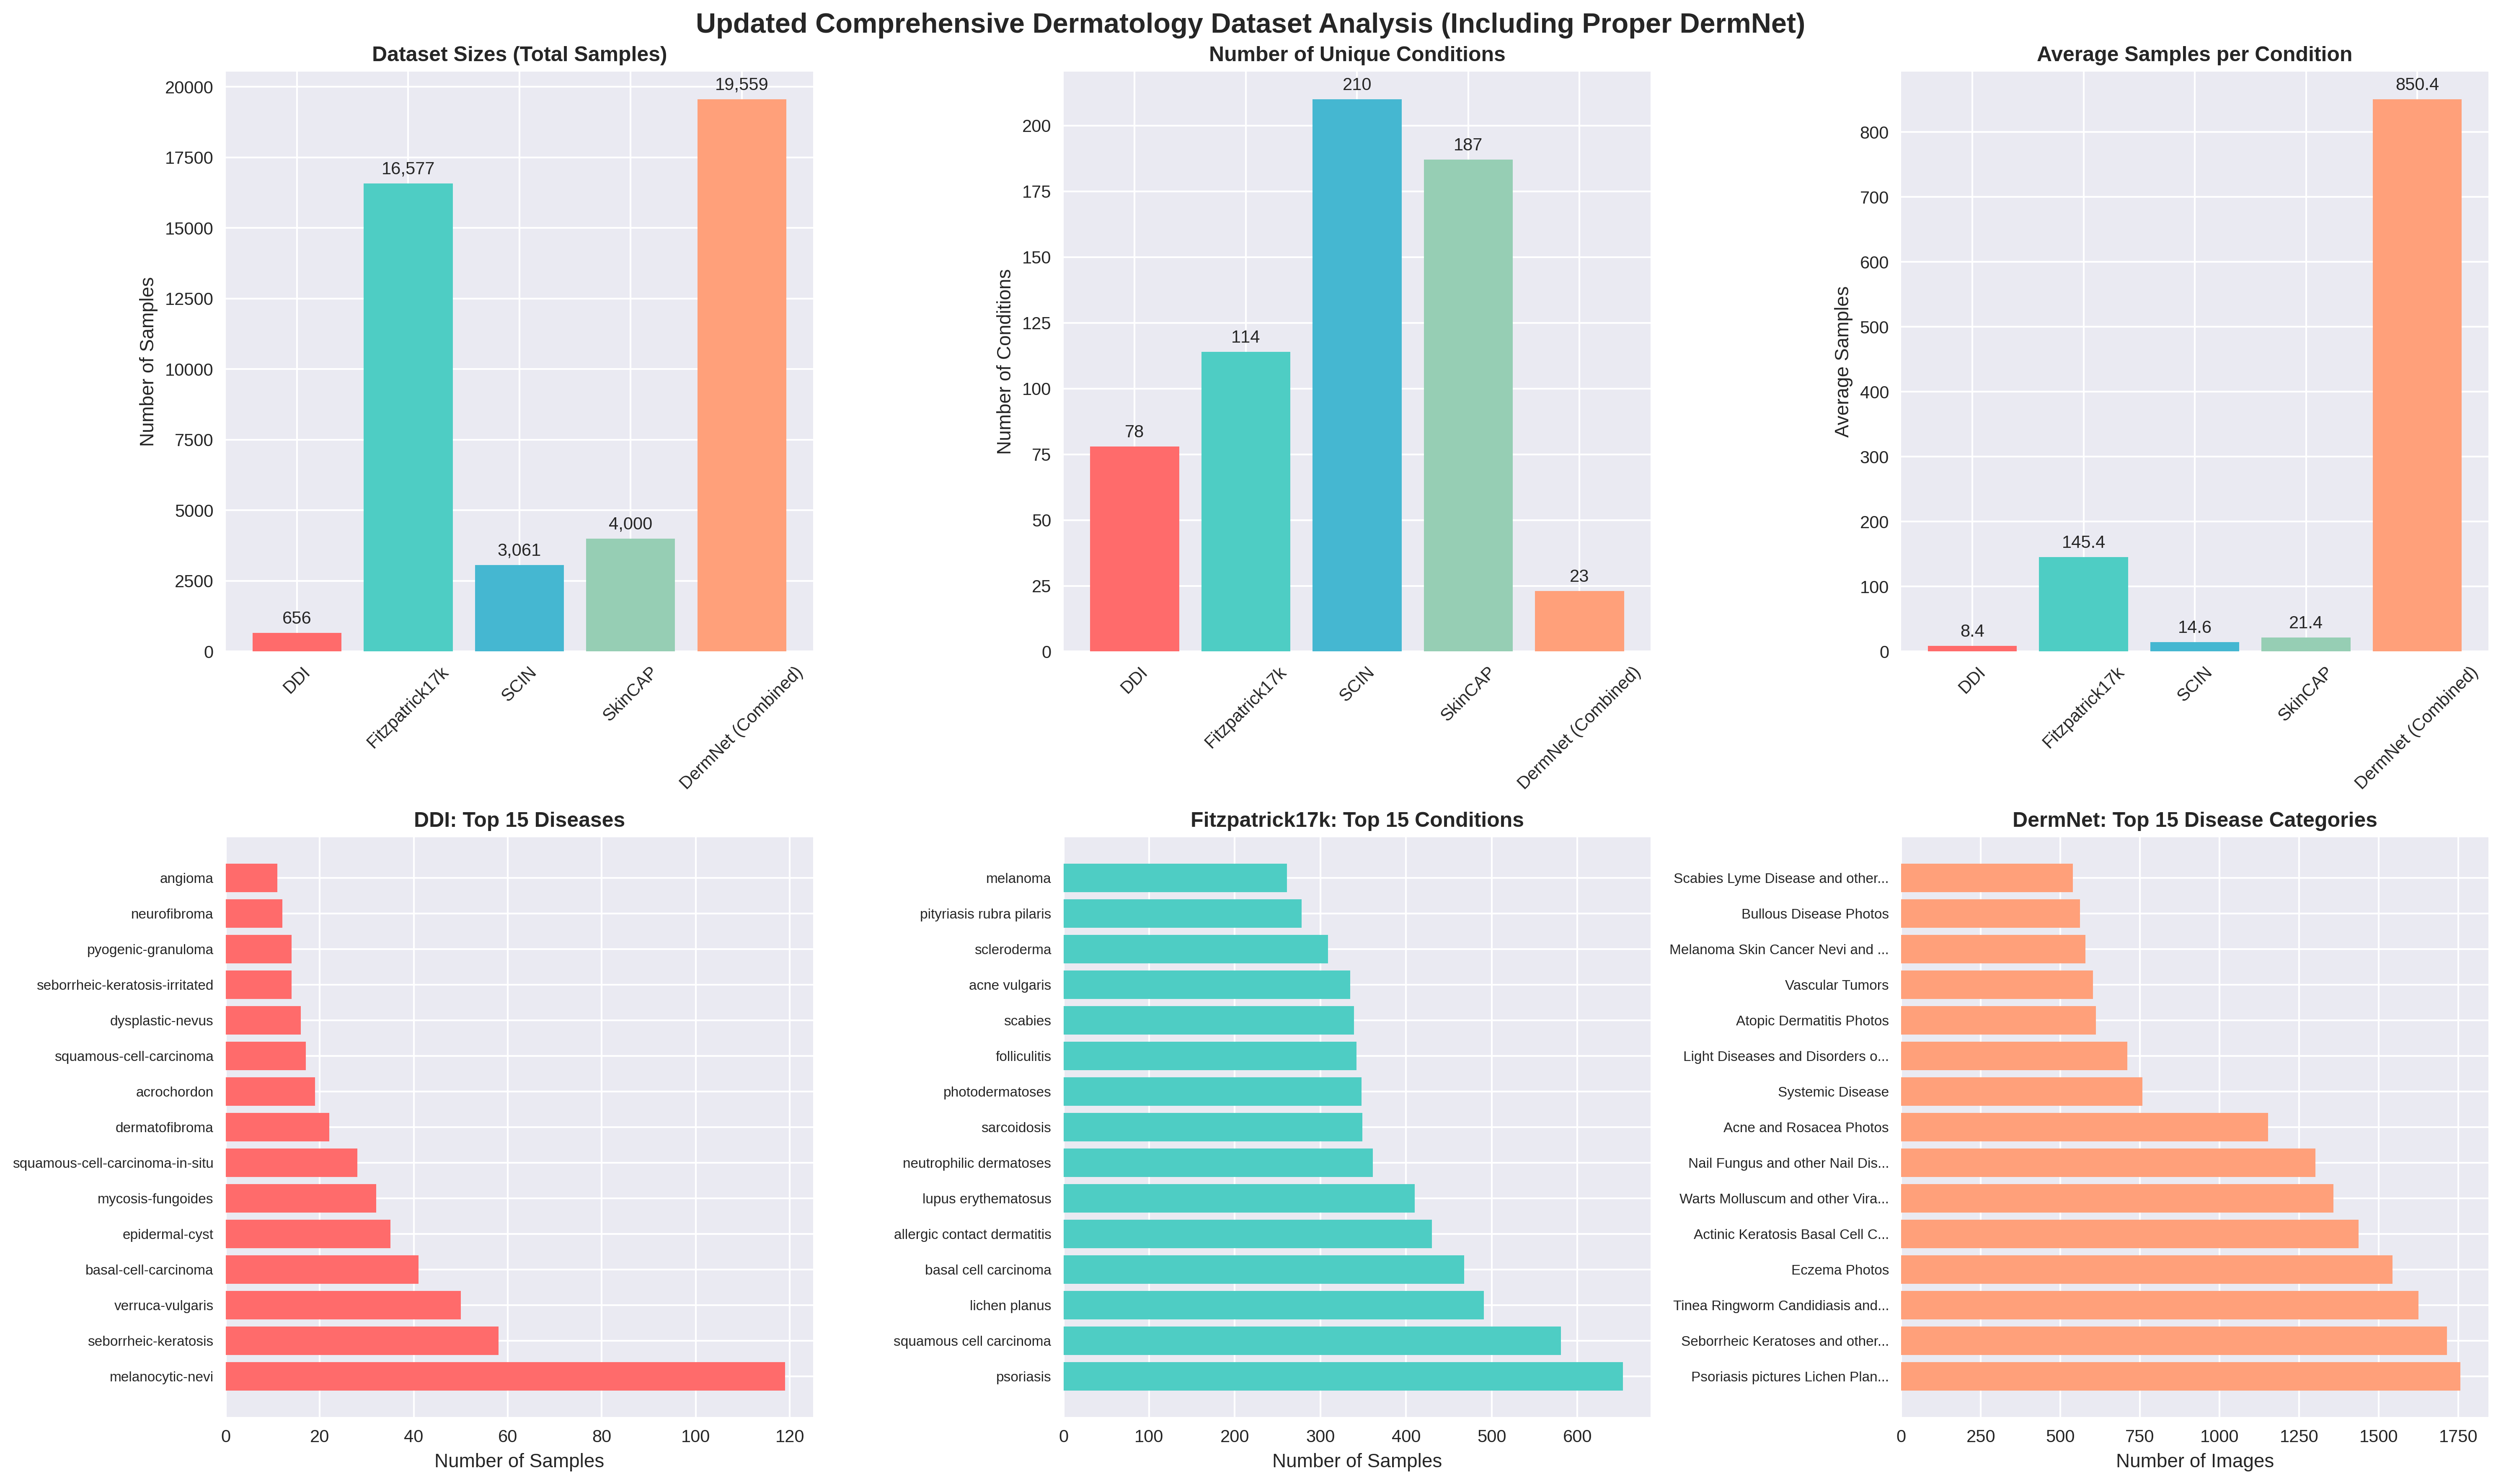

Updated comprehensive analysis visualization saved as 'updated_comprehensive_dermatology_dataset_analysis.png'


In [78]:
# Create updated comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Updated Comprehensive Dermatology Dataset Analysis (Including Proper DermNet)', fontsize=16, fontweight='bold')

# 1. Dataset sizes comparison
axes[0, 0].bar(updated_dataset_stats['Dataset'], updated_dataset_stats['Total Samples'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFA07A'])
axes[0, 0].set_title('Dataset Sizes (Total Samples)', fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(updated_dataset_stats['Total Samples']):
    axes[0, 0].text(i, v + max(updated_dataset_stats['Total Samples'])*0.01, f'{v:,}', ha='center', va='bottom')

# 2. Number of unique conditions
axes[0, 1].bar(updated_dataset_stats['Dataset'], updated_dataset_stats['Unique Conditions'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFA07A'])
axes[0, 1].set_title('Number of Unique Conditions', fontweight='bold')
axes[0, 1].set_ylabel('Number of Conditions')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(updated_dataset_stats['Unique Conditions']):
    axes[0, 1].text(i, v + max(updated_dataset_stats['Unique Conditions'])*0.01, f'{v}', ha='center', va='bottom')

# 3. Average samples per condition
axes[0, 2].bar(updated_dataset_stats['Dataset'], updated_dataset_stats['Avg Samples per Condition'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFA07A'])
axes[0, 2].set_title('Average Samples per Condition', fontweight='bold')
axes[0, 2].set_ylabel('Average Samples')
axes[0, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(updated_dataset_stats['Avg Samples per Condition']):
    axes[0, 2].text(i, v + max(updated_dataset_stats['Avg Samples per Condition'])*0.01, f'{v:.1f}', ha='center', va='bottom')

# 4. Label distribution for DDI
ddi_counts = ddi_df['disease'].value_counts().head(15)
axes[1, 0].barh(range(len(ddi_counts)), ddi_counts.values, color='#FF6B6B')
axes[1, 0].set_yticks(range(len(ddi_counts)))
axes[1, 0].set_yticklabels(ddi_counts.index, fontsize=8)
axes[1, 0].set_title('DDI: Top 15 Diseases', fontweight='bold')
axes[1, 0].set_xlabel('Number of Samples')

# 5. Label distribution for Fitzpatrick17k
fitz_counts = fitz_df['label'].value_counts().head(15)
axes[1, 1].barh(range(len(fitz_counts)), fitz_counts.values, color='#4ECDC4')
axes[1, 1].set_yticks(range(len(fitz_counts)))
axes[1, 1].set_yticklabels(fitz_counts.index, fontsize=8)
axes[1, 1].set_title('Fitzpatrick17k: Top 15 Conditions', fontweight='bold')
axes[1, 1].set_xlabel('Number of Samples')

# 6. Label distribution for DermNet (top 15)
dermnet_top_15 = dermnet_df.head(15)
axes[1, 2].barh(range(len(dermnet_top_15)), dermnet_top_15['total_images'], color='#FFA07A')
axes[1, 2].set_yticks(range(len(dermnet_top_15)))
axes[1, 2].set_yticklabels([disease[:30] + '...' if len(disease) > 30 else disease for disease in dermnet_top_15['disease']], fontsize=8)
axes[1, 2].set_title('DermNet: Top 15 Disease Categories', fontweight='bold')
axes[1, 2].set_xlabel('Number of Images')

plt.tight_layout()
plt.savefig('updated_comprehensive_dermatology_dataset_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Updated comprehensive analysis visualization saved as 'updated_comprehensive_dermatology_dataset_analysis.png'")


## 5. Final Summary and Recommendations


In [79]:
# Generate final summary recommendations
print("=" * 80)
print("FINAL COMPREHENSIVE DATASET ANALYSIS SUMMARY (INCLUDING PROPER DERMNET)")
print("=" * 80)

print("\n📊 FINAL DATASET OVERVIEW:")
print(f"• Total samples across all datasets: {updated_total_samples:,}")
print(f"• Total unique conditions: {updated_total_conditions}")
print(f"• Average samples per condition: {updated_total_samples/updated_total_conditions:.1f}")

print("\n🏆 FINAL DATASET RANKINGS:")

print("\nBy Total Samples:")
for i, (dataset, samples) in enumerate(sorted(zip(updated_dataset_stats['Dataset'], updated_dataset_stats['Total Samples']), 
                                            key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {samples:,} samples")

print("\nBy Number of Conditions:")
for i, (dataset, conditions) in enumerate(sorted(zip(updated_dataset_stats['Dataset'], updated_dataset_stats['Unique Conditions']), 
                                              key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {conditions} conditions")

print("\nBy Average Samples per Condition:")
for i, (dataset, avg) in enumerate(sorted(zip(updated_dataset_stats['Dataset'], updated_dataset_stats['Avg Samples per Condition']), 
                                        key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {avg:.1f} samples/condition")

print("\n🎯 DERMNET INSIGHTS:")
print(f"• DermNet provides {total_combined_images:,} images across {total_disease_categories} disease categories")
print(f"• Train/Test split: {total_train_images:,} / {total_test_images:,} images")
print(f"• Training suitability: {len(trainable_diseases)}/{total_disease_categories} diseases have ≥20 images")
print(f"• Class imbalance ratio: {imbalance_ratio:.1f}:1 (max/min)")
print(f"• Most common disease: {dermnet_df.iloc[0]['disease']} ({dermnet_df.iloc[0]['total_images']} images)")
print(f"• Least common disease: {dermnet_df.iloc[-1]['disease']} ({dermnet_df.iloc[-1]['total_images']} images)")

print("\n💡 FINAL RECOMMENDATIONS FOR TRAINING:")

print("\n1. BEST DATASETS FOR TRAINING:")
print("   • DermNet: Largest dataset with comprehensive disease coverage and proper train/test split")
print("   • Fitzpatrick17k: Excellent balance and quality")
print("   • SCIN: High-quality dermatologist annotations")
print("   • SkinCAP: Good variety with morphological features")
print("   • DDI: Specific rare conditions")

print("\n2. OPTIMAL TRAINING STRATEGY:")
print("   • Primary: DermNet (largest dataset with proper train/test split)")
print("   • Secondary: Fitzpatrick17k (balanced quality)")
print("   • Supplement: SCIN (expert annotations)")
print("   • Additional: SkinCAP (morphological diversity)")
print("   • Rare cases: DDI (specific conditions)")

print("\n3. DERMNET-SPECIFIC TRAINING APPROACH:")
print("   • Use provided train/test split for proper evaluation")
print("   • Focus on diseases with ≥20 images for reliable training")
print("   • Apply stratified sampling within each disease category")
print("   • Use data augmentation for underrepresented diseases")
print("   • Consider hierarchical classification (common vs rare diseases)")

print("\n4. CLASS IMBALANCE MITIGATION:")
print("   • Use weighted loss functions based on class frequency")
print("   • Apply focal loss for extreme imbalance")
print("   • Implement progressive training (start with balanced subset)")
print("   • Use stratified sampling across all datasets")
print("   • Consider oversampling for rare diseases")

print("\n5. VALIDATION APPROACH:")
print("   • Use DermNet's provided test set for final evaluation")
print("   • Cross-dataset validation for generalization testing")
print("   • Stratified splits within each dataset")
print("   • Test on both common and rare conditions")

print("\n6. COMPUTATIONAL REQUIREMENTS:")
print(f"   • Total images to process: {updated_total_samples:,}")
print("   • Recommended batch size: 32-64")
print("   • Estimated training time: 3-5 days on modern GPU")
print("   • Storage requirement: ~100-200GB for processed data")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE! DermNet properly analyzed with combined train/test disease categories.")
print("=" * 80)


FINAL COMPREHENSIVE DATASET ANALYSIS SUMMARY (INCLUDING PROPER DERMNET)

📊 FINAL DATASET OVERVIEW:
• Total samples across all datasets: 43,853
• Total unique conditions: 612
• Average samples per condition: 71.7

🏆 FINAL DATASET RANKINGS:

By Total Samples:
  1. DermNet (Combined): 19,559 samples
  2. Fitzpatrick17k: 16,577 samples
  3. SkinCAP: 4,000 samples
  4. SCIN: 3,061 samples
  5. DDI: 656 samples

By Number of Conditions:
  1. SCIN: 210 conditions
  2. SkinCAP: 187 conditions
  3. Fitzpatrick17k: 114 conditions
  4. DDI: 78 conditions
  5. DermNet (Combined): 23 conditions

By Average Samples per Condition:
  1. DermNet (Combined): 850.4 samples/condition
  2. Fitzpatrick17k: 145.4 samples/condition
  3. SkinCAP: 21.4 samples/condition
  4. SCIN: 14.6 samples/condition
  5. DDI: 8.4 samples/condition

🎯 DERMNET INSIGHTS:
• DermNet provides 19,559 images across 23 disease categories
• Train/Test split: 15,557 / 4,002 images
• Training suitability: 23/23 diseases have ≥20 images

# Comprehensive Dermatology Dataset Analysis

This notebook provides a unified analysis of all available dermatology datasets:
- **DDI (Diverse Dermatology Images)**: 656 samples, 78 diseases
- **Fitzpatrick17k**: 16,577 samples, 114 diseases
- **SCIN**: 5,033 samples, 60+ skin conditions
- **SkinCAP**: 4,000+ samples, 50+ diseases
- **DermaVQA**: Question-answering dataset with dermatology cases


In [80]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better quality
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10


## 1. Load All Datasets


In [82]:
# Load DDI dataset
ddi_df = pd.read_csv('data/ddidiversedermatologyimages/ddi_metadata.csv')
print(f"DDI Dataset: {ddi_df.shape[0]} samples, {ddi_df['disease'].nunique()} diseases")

# Load Fitzpatrick17k dataset
fitz_df = pd.read_csv('data/fitzpatrick17k/fitzpatrick17k.csv')
print(f"Fitzpatrick17k Dataset: {fitz_df.shape[0]} samples, {fitz_df['label'].nunique()} diseases")

# Load SCIN dataset
scin_df = pd.read_csv('data/scin/dataset/scin_labels.csv')
print(f"SCIN Dataset: {scin_df.shape[0]} samples")

# Load SkinCAP dataset
skincap_df = pd.read_csv('data/skincap/skincap_v240623.csv')
print(f"SkinCAP Dataset: {skincap_df.shape[0]} samples, {skincap_df['disease'].nunique()} diseases")

print("\nAll datasets loaded successfully!")


DDI Dataset: 656 samples, 78 diseases
Fitzpatrick17k Dataset: 16577 samples, 114 diseases
SCIN Dataset: 5033 samples
SkinCAP Dataset: 4000 samples, 187 diseases

All datasets loaded successfully!


## 2. Process SCIN Dataset (Extract Most Confident Labels)


In [83]:
# Function to extract the most confident label from SCIN dataset
def get_most_confident_label(row):
    try:
        labels = ast.literal_eval(row['dermatologist_skin_condition_on_label_name'])
        confidences = ast.literal_eval(row['dermatologist_skin_condition_confidence'])
        
        if not labels or not confidences:
            return None
            
        max_conf_idx = np.argmax(confidences)
        return labels[max_conf_idx]
        
    except (ValueError, SyntaxError, TypeError):
        return None

# Apply the function to get most confident labels
scin_df['most_confident_label'] = scin_df.apply(get_most_confident_label, axis=1)
scin_df_with_labels = scin_df.dropna(subset=['most_confident_label'])

print(f"SCIN Dataset with valid labels: {scin_df_with_labels.shape[0]} samples, {scin_df_with_labels['most_confident_label'].nunique()} unique conditions")
print(f"Label extraction success rate: {len(scin_df_with_labels)/len(scin_df)*100:.1f}%")


SCIN Dataset with valid labels: 3061 samples, 210 unique conditions
Label extraction success rate: 60.8%


## 3. Dataset Overview Statistics


In [84]:
# Create dataset overview
dataset_stats = {
    'Dataset': ['DDI', 'Fitzpatrick17k', 'SCIN', 'SkinCAP'],
    'Total Samples': [
        ddi_df.shape[0],
        fitz_df.shape[0],
        scin_df_with_labels.shape[0],
        skincap_df.shape[0]
    ],
    'Unique Conditions': [
        ddi_df['disease'].nunique(),
        fitz_df['label'].nunique(),
        scin_df_with_labels['most_confident_label'].nunique(),
        skincap_df['disease'].nunique()
    ],
    'Avg Samples per Condition': [
        ddi_df.shape[0] / ddi_df['disease'].nunique(),
        fitz_df.shape[0] / fitz_df['label'].nunique(),
        scin_df_with_labels.shape[0] / scin_df_with_labels['most_confident_label'].nunique(),
        skincap_df.shape[0] / skincap_df['disease'].nunique()
    ]
}

overview_df = pd.DataFrame(dataset_stats)
print("Dataset Overview:")
print(overview_df.to_string(index=False))

# Calculate total samples across all datasets
total_samples = sum(dataset_stats['Total Samples'])
total_conditions = sum(dataset_stats['Unique Conditions'])
print(f"\nTotal across all datasets: {total_samples:,} samples, {total_conditions} unique conditions")


Dataset Overview:
       Dataset  Total Samples  Unique Conditions  Avg Samples per Condition
           DDI            656                 78                   8.410256
Fitzpatrick17k          16577                114                 145.412281
          SCIN           3061                210                  14.576190
       SkinCAP           4000                187                  21.390374

Total across all datasets: 24,294 samples, 589 unique conditions


## 4. Comprehensive Visualization: Dataset Comparison


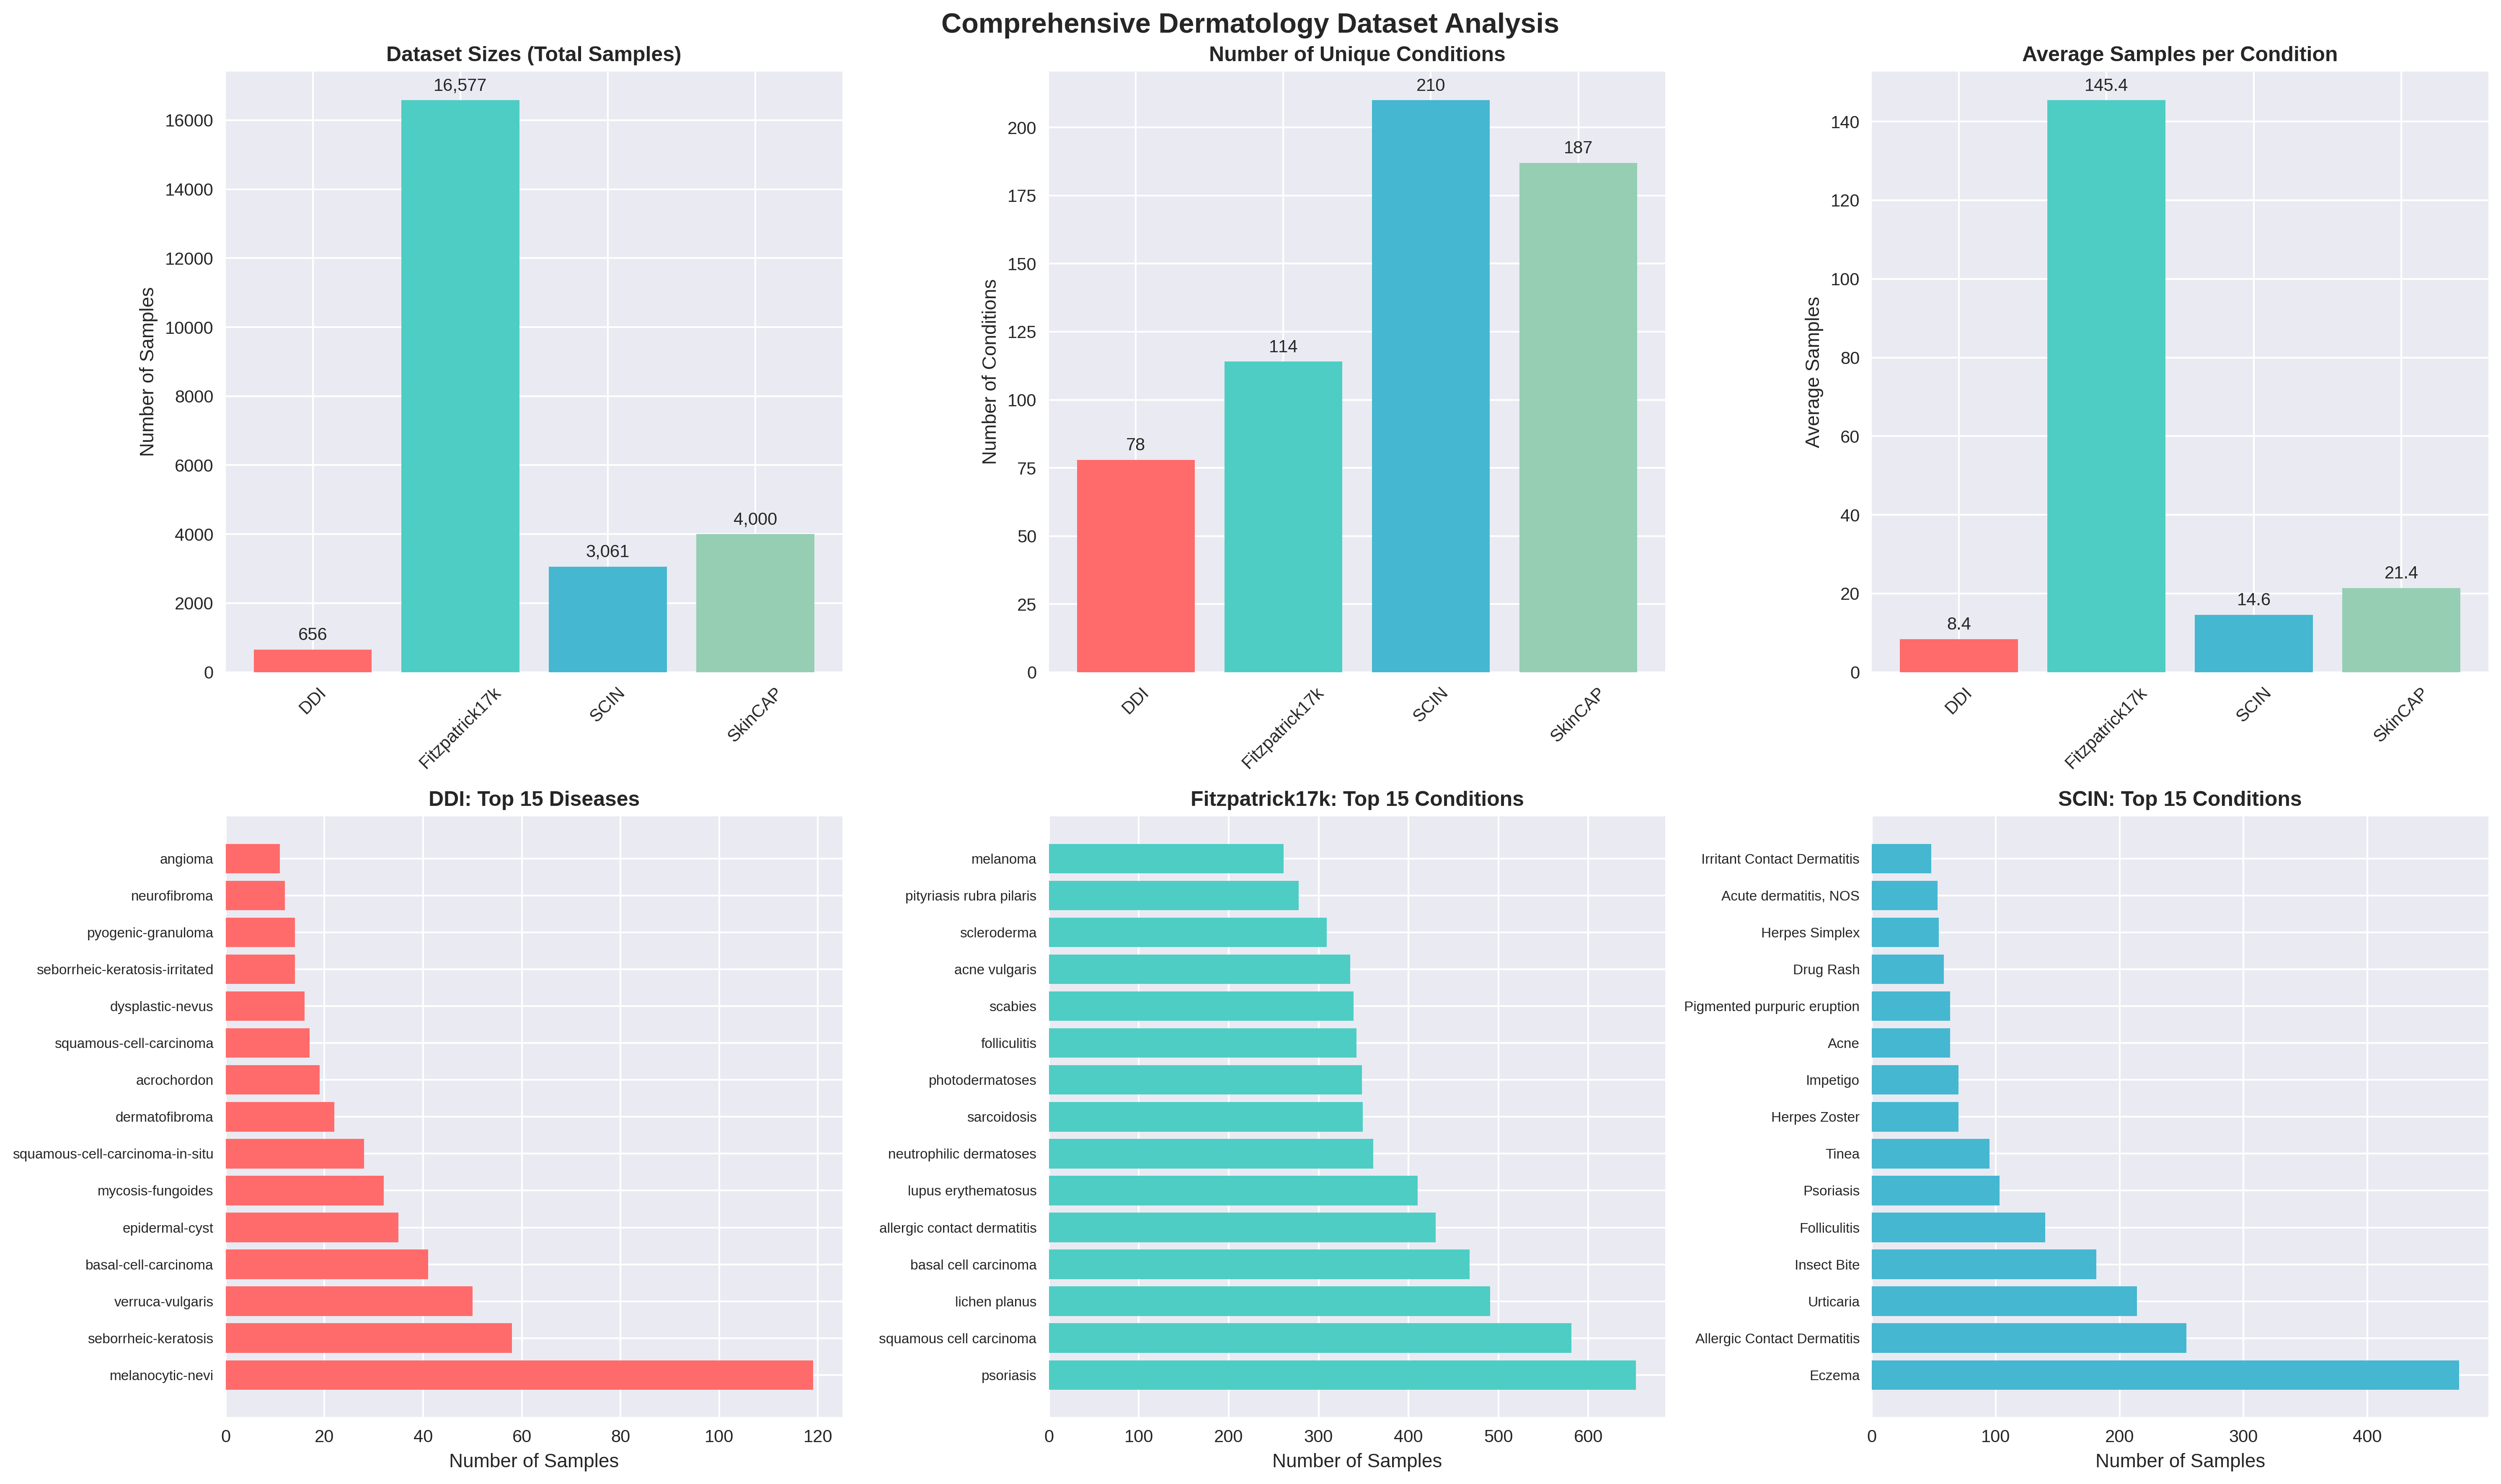

Comprehensive analysis visualization saved as 'comprehensive_dermatology_dataset_analysis.png'


In [85]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comprehensive Dermatology Dataset Analysis', fontsize=16, fontweight='bold')

# 1. Dataset sizes comparison
axes[0, 0].bar(dataset_stats['Dataset'], dataset_stats['Total Samples'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 0].set_title('Dataset Sizes (Total Samples)', fontweight='bold')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(dataset_stats['Total Samples']):
    axes[0, 0].text(i, v + max(dataset_stats['Total Samples'])*0.01, f'{v:,}', ha='center', va='bottom')

# 2. Number of unique conditions
axes[0, 1].bar(dataset_stats['Dataset'], dataset_stats['Unique Conditions'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 1].set_title('Number of Unique Conditions', fontweight='bold')
axes[0, 1].set_ylabel('Number of Conditions')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(dataset_stats['Unique Conditions']):
    axes[0, 1].text(i, v + max(dataset_stats['Unique Conditions'])*0.01, f'{v}', ha='center', va='bottom')

# 3. Average samples per condition
axes[0, 2].bar(dataset_stats['Dataset'], dataset_stats['Avg Samples per Condition'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 2].set_title('Average Samples per Condition', fontweight='bold')
axes[0, 2].set_ylabel('Average Samples')
axes[0, 2].tick_params(axis='x', rotation=45)
for i, v in enumerate(dataset_stats['Avg Samples per Condition']):
    axes[0, 2].text(i, v + max(dataset_stats['Avg Samples per Condition'])*0.01, f'{v:.1f}', ha='center', va='bottom')

# 4. Label distribution for DDI
ddi_counts = ddi_df['disease'].value_counts().head(15)
axes[1, 0].barh(range(len(ddi_counts)), ddi_counts.values, color='#FF6B6B')
axes[1, 0].set_yticks(range(len(ddi_counts)))
axes[1, 0].set_yticklabels(ddi_counts.index, fontsize=8)
axes[1, 0].set_title('DDI: Top 15 Diseases', fontweight='bold')
axes[1, 0].set_xlabel('Number of Samples')

# 5. Label distribution for Fitzpatrick17k
fitz_counts = fitz_df['label'].value_counts().head(15)
axes[1, 1].barh(range(len(fitz_counts)), fitz_counts.values, color='#4ECDC4')
axes[1, 1].set_yticks(range(len(fitz_counts)))
axes[1, 1].set_yticklabels(fitz_counts.index, fontsize=8)
axes[1, 1].set_title('Fitzpatrick17k: Top 15 Conditions', fontweight='bold')
axes[1, 1].set_xlabel('Number of Samples')

# 6. Label distribution for SCIN
scin_counts = scin_df_with_labels['most_confident_label'].value_counts().head(15)
axes[1, 2].barh(range(len(scin_counts)), scin_counts.values, color='#45B7D1')
axes[1, 2].set_yticks(range(len(scin_counts)))
axes[1, 2].set_yticklabels(scin_counts.index, fontsize=8)
axes[1, 2].set_title('SCIN: Top 15 Conditions', fontweight='bold')
axes[1, 2].set_xlabel('Number of Samples')

plt.tight_layout()
plt.savefig('comprehensive_dermatology_dataset_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comprehensive analysis visualization saved as 'comprehensive_dermatology_dataset_analysis.png'")


## 5. Summary and Recommendations


In [86]:
# Generate summary recommendations
print("=" * 80)
print("COMPREHENSIVE DATASET ANALYSIS SUMMARY")
print("=" * 80)

print("\n📊 DATASET OVERVIEW:")
print(f"• Total samples across all datasets: {total_samples:,}")
print(f"• Total unique conditions: {total_conditions}")
print(f"• Average samples per condition: {total_samples/total_conditions:.1f}")

print("\n🏆 DATASET RANKINGS:")
print("\nBy Total Samples:")
for i, (dataset, samples) in enumerate(sorted(zip(dataset_stats['Dataset'], dataset_stats['Total Samples']), 
                                            key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {samples:,} samples")

print("\nBy Number of Conditions:")
for i, (dataset, conditions) in enumerate(sorted(zip(dataset_stats['Dataset'], dataset_stats['Unique Conditions']), 
                                              key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {conditions} conditions")

print("\nBy Average Samples per Condition:")
for i, (dataset, avg) in enumerate(sorted(zip(dataset_stats['Dataset'], dataset_stats['Avg Samples per Condition']), 
                                        key=lambda x: x[1], reverse=True), 1):
    print(f"  {i}. {dataset}: {avg:.1f} samples/condition")

print("\n💡 RECOMMENDATIONS FOR TRAINING:")
print("\n1. BEST DATASETS FOR TRAINING:")
print("   • Fitzpatrick17k: Largest dataset with good balance")
print("   • SCIN: High-quality dermatologist annotations")
print("   • SkinCAP: Good variety with morphological features")

print("\n2. CLASS IMBALANCE CONSIDERATIONS:")
print("   • Use stratified sampling to ensure balanced training")
print("   • Consider data augmentation for underrepresented classes")
print("   • Focus on classes with ≥20 samples for reliable training")

print("\n3. COMBINED TRAINING STRATEGY:")
print("   • Use Fitzpatrick17k as primary dataset (largest)")
print("   • Supplement with SCIN for high-quality annotations")
print("   • Add SkinCAP for morphological feature diversity")
print("   • Use DDI for specific rare conditions")

print("\n4. VALIDATION APPROACH:")
print("   • Cross-dataset validation for generalization testing")
print("   • Hold out one dataset entirely for final evaluation")
print("   • Use stratified splits within each dataset")

print("\n" + "=" * 80)
print("Analysis complete! Check the generated visualizations for detailed insights.")
print("=" * 80)


COMPREHENSIVE DATASET ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
• Total samples across all datasets: 24,294
• Total unique conditions: 589
• Average samples per condition: 41.2

🏆 DATASET RANKINGS:

By Total Samples:
  1. Fitzpatrick17k: 16,577 samples
  2. SkinCAP: 4,000 samples
  3. SCIN: 3,061 samples
  4. DDI: 656 samples

By Number of Conditions:
  1. SCIN: 210 conditions
  2. SkinCAP: 187 conditions
  3. Fitzpatrick17k: 114 conditions
  4. DDI: 78 conditions

By Average Samples per Condition:
  1. Fitzpatrick17k: 145.4 samples/condition
  2. SkinCAP: 21.4 samples/condition
  3. SCIN: 14.6 samples/condition
  4. DDI: 8.4 samples/condition

💡 RECOMMENDATIONS FOR TRAINING:

1. BEST DATASETS FOR TRAINING:
   • Fitzpatrick17k: Largest dataset with good balance
   • SCIN: High-quality dermatologist annotations
   • SkinCAP: Good variety with morphological features

2. CLASS IMBALANCE CONSIDERATIONS:
   • Use stratified sampling to ensure balanced training
   • Consider data augmentation fo

In [87]:
# Export DermNet dataset analysis to CSV
print("=" * 60)
print("EXPORTING DERMNET DATASET ANALYSIS TO CSV")
print("=" * 60)

# Create export DataFrame with all disease information
export_data = []

for disease_name in combined_disease_counts.keys():
    train_count = train_disease_counts.get(disease_name, 0)
    test_count = test_disease_counts.get(disease_name, 0)
    total_count = combined_disease_counts[disease_name]
    
    export_data.append({
        'disease_name': disease_name,
        'train_images': train_count,
        'test_images': test_count,
        'total_images': total_count,
        'train_percentage': (train_count / total_count * 100) if total_count > 0 else 0,
        'test_percentage': (test_count / total_count * 100) if total_count > 0 else 0
    })

# Create DataFrame and sort by total images
export_df = pd.DataFrame(export_data).sort_values('total_images', ascending=False)

# Add ranking column
export_df['rank'] = range(1, len(export_df) + 1)

# Reorder columns for better readability
export_df = export_df[['rank', 'disease_name', 'total_images', 'train_images', 'test_images', 
                       'train_percentage', 'test_percentage']]

# Export to CSV
csv_filename = 'dermnet_disease_analysis.csv'
export_df.to_csv(csv_filename, index=False)

print(f"\n📊 EXPORTED DATA SUMMARY:")
print(f"• Total diseases exported: {len(export_df)}")
print(f"• Total images: {export_df['total_images'].sum():,}")
print(f"• CSV file saved as: {csv_filename}")

print(f"\n📋 PREVIEW OF EXPORTED DATA:")
print(export_df.head(10).to_string(index=False))

print(f"\n📈 STATISTICS:")
print(f"• Average images per disease: {export_df['total_images'].mean():.1f}")
print(f"• Median images per disease: {export_df['total_images'].median():.1f}")
print(f"• Most common disease: {export_df.iloc[0]['disease_name']} ({export_df.iloc[0]['total_images']} images)")
print(f"• Least common disease: {export_df.iloc[-1]['disease_name']} ({export_df.iloc[-1]['total_images']} images)")

print(f"\n✅ CSV file '{csv_filename}' has been successfully created!")
print("The file contains the following columns:")
print("• rank: Ranking by total image count")
print("• disease_name: Name of the disease category")
print("• total_images: Combined train + test image count")
print("• train_images: Number of images in training set")
print("• test_images: Number of images in test set")
print("• train_percentage: Percentage of images in training set")
print("• test_percentage: Percentage of images in test set")


EXPORTING DERMNET DATASET ANALYSIS TO CSV

📊 EXPORTED DATA SUMMARY:
• Total diseases exported: 23
• Total images: 19,559
• CSV file saved as: dermnet_disease_analysis.csv

📋 PREVIEW OF EXPORTED DATA:
 rank                                                       disease_name  total_images  train_images  test_images  train_percentage  test_percentage
    1              Psoriasis pictures Lichen Planus and related diseases          1757          1405          352         79.965851        20.034149
    2                       Seborrheic Keratoses and other Benign Tumors          1714          1371          343         79.988331        20.011669
    3             Tinea Ringworm Candidiasis and other Fungal Infections          1625          1300          325         80.000000        20.000000
    4                                                      Eczema Photos          1544          1235          309         79.987047        20.012953
    5 Actinic Keratosis Basal Cell Carcinoma and other 